#📌 Extracción

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df_raw = pd.read_json(url)

# Normalizar estructura anidada
df = pd.json_normalize(df_raw.to_dict(orient='records'))

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#🔧 Transformación

In [8]:
# 1- Limpiar nombres columnas
df.columns = df.columns.str.replace('.', '_')

# 2- Eliminar churn vacío
df = df[df['Churn'] != '']

# 3- Convertir churn a binario
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# 4- Convertir Total Charges a numérico
df['account_Charges_Total'] = pd.to_numeric(
    df['account_Charges_Total'], errors='coerce'
)

# 5- Eliminar nulos en total charges
df = df.dropna(subset=['account_Charges_Total'])

# 6. Revisar duplicados
df.duplicated().sum()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   object 
 5   customer_Dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   object 
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   object 
 1

#📊 Carga y análisis

## **Análisis descriptivo general**

In [16]:
df.describe()
df.describe(include='object')

,customerID,customer_gender,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


El dataset contiene 7032 registros después del proceso de limpieza. Las variables numéricas presentan distribuciones coherentes con el comportamiento esperado en clientes de telecomunicaciones.

## **Distribución general de Churn**

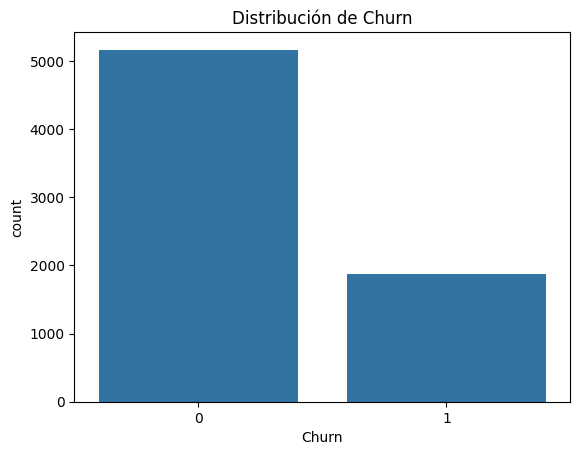

In [17]:
df['Churn'].value_counts(normalize=True) * 100
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Distribución de Churn')
plt.show()

La tasa de evasión general es de 26.58%, lo que indica que aproximadamente uno de cada cuatro clientes cancela el servicio. Este nivel de churn es considerable y justifica un análisis detallado para identificar los factores asociados a la pérdida de clientes.

### **Churn por tipo de contrato**

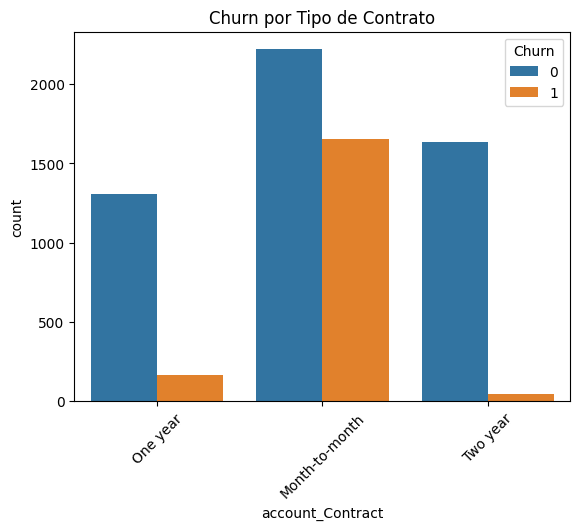

,Churn
account_Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


In [19]:
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.xticks(rotation=45)
plt.show()

df.groupby('account_Contract')['Churn'].mean() * 100

Se observa que los clientes con contratos mes a mes presentan una tasa de evasión significativamente mayor (42.7%) en comparación con contratos anuales (11.3%) y contratos de dos años (2.8%). Esto sugiere que la duración del contrato es uno de los principales factores asociados a la cancelación del servicio.

### **Churn vs Antigüedad (Tenure)**

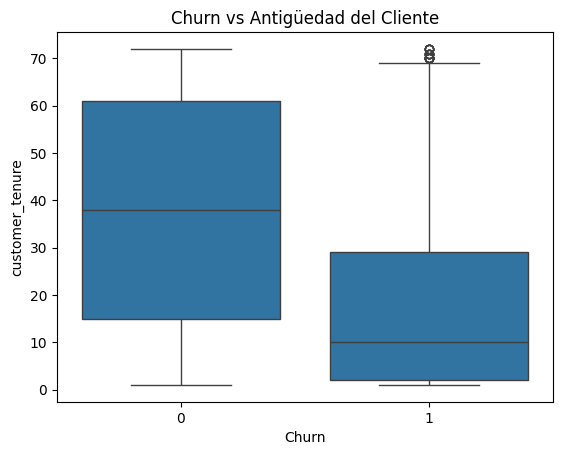

,customer_tenure
Churn,
0,37.650010
1,17.979133


In [18]:
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Churn vs Antigüedad del Cliente')
plt.show()

df.groupby('Churn')['customer_tenure'].mean()

Los clientes que cancelan el servicio presentan una antigüedad promedio de 17.98 meses, mientras que los clientes que permanecen tienen una antigüedad promedio de 37.85 meses.

Esto indica que los clientes nuevos presentan mayor probabilidad de cancelar el servicio. Los primeros meses son críticos para la retención.

### **Churn vs Cargos Mensuales**

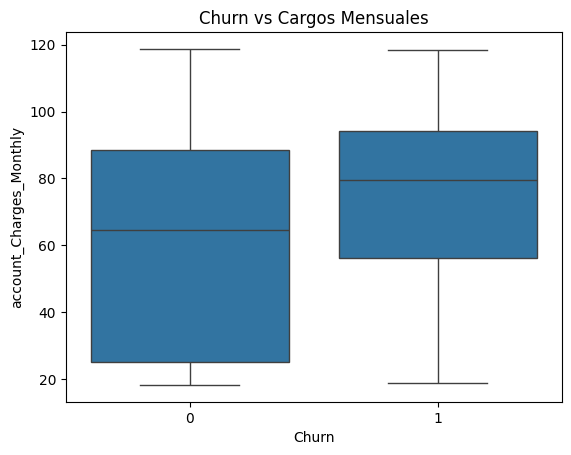

,account_Charges_Monthly
Churn,
0,61.307408
1,74.441332


In [21]:
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df)
plt.title('Churn vs Cargos Mensuales')
plt.show()

df.groupby('Churn')['account_Charges_Monthly'].mean()

Los clientes que cancelan el servicio presentan un cargo mensual promedio de 74.44, mientras que los clientes que permanecen tienen un promedio de 61.30.

Esto sugiere que cargos mensuales más altos están asociados con una mayor probabilidad de evasión. Clientes que perciben un costo elevado podrían estar más propensos a cancelar el servicio.

#📄Informe final